# Allen-Cahn PDE

## Task Incremental Learning - Task0

### Experiments nomenclature

`L`[learning_mode]

- learning_mode $\in$ \{$w_1+...+w_k$ | \{$w_1, ..., w_k$\} $\in \mathcal{P}$(\{`pinn`, `out`, `der`, `hes`\})\}

### Experiments location

**AllenCahn**

- **Task0**
    - **models0** | ... | **modelsM**
        - **tiral0** | ... | **trialN**
            - model.pth, training stats files

In [ ]:
import torch
from torch.utils.data import TensorDataset, ConcatDataset
from data_utils import compute_prediction_difference, compute_prediction, extract_targets
from plot_utils import plot_loss_comp, plot_model_stats, print_model_info, plot_points_grid, plot_model_stats_grid, print_model_performances, plot_model_performances, plot_performance_comparison
from load_store_utils import load_stats, resume_model
from train import start_train
from typing import List
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from tqdm import tqdm
# ---------------------
TRAIN = True
SAVE_PLOTS = True
CROSS_THE_RUBICON = False

PDE = "AllenCahn"
PDE_NAME = "Allen-Cahn"
SEED = 42
ACTUAL_MODE = "PINN"
TASK = 0
N_EPOCHS = 200

LR_MODE = "CosAnn"
DWA_MODE = "Norm1"
CLIP_GRAD = True
# ---------------------
BATCH_SIZE = 1024

if LR_MODE == "ExpDec":
    LR = "_ExpLrDecay"
else:
    LR_MODE = "CosAnn"
    LR = "_CosLrAnnealing"
    
if not CLIP_GRAD:
    CLIP = "NoGradClip"
else:
    CLIP = "GradClip"

/home/claudia/tesi/ANN_fisica/code/code/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Functions to work with the A-C dataset

In [2]:
def merge_ds(datasets: List[TensorDataset]) -> TensorDataset:
    cols = None   
    for ds in datasets:
        new_cols = list(ds.tensors)
        if cols is None:
            cols = new_cols
        else:
            for i, col in enumerate(new_cols):
                cols[i] = torch.cat([cols[i], col])
    return TensorDataset(*cols)

def prepare_dataset(datasets: List[ConcatDataset]) -> ConcatDataset:
    n_snapshots = len(datasets[0].datasets)
    data = [None for _ in range(n_snapshots)]
    for i in range(n_snapshots):
        data[i] = merge_ds([concat_ds.datasets[i] for concat_ds in datasets])
    return ConcatDataset(data)

### Load datasets

In [3]:
full_datasets = torch.load(f"{PDE}/data/full_datasets.pth", weights_only=False).datasets
unlabeled_datasets = torch.load(f"{PDE}/data/unlabeled_datasets.pth", weights_only=False).datasets
dev_datasets = torch.load(f"{PDE}/data/dev_datasets.pth", weights_only=False).datasets
train_datasets = torch.load(f"{PDE}/data/train_datasets.pth", weights_only=False).datasets
val_datasets = torch.load(f"{PDE}/data/val_datasets.pth", weights_only=False).datasets
inter_test_datasets = torch.load(f"{PDE}/data/inter_test_datasets.pth", weights_only=False).datasets
intra_test_datasets = torch.load(f"{PDE}/data/intra_test_datasets.pth", weights_only=False).datasets

n_params = 2 # number of xi_j

n = 4 # param vectors values per (composed) task
n_tasks = int(len(dev_datasets)/n)

train_task = [None for _ in range(n_tasks)]
intra_test_task = [None for _ in range(n_tasks)]
nl_task = [None for _ in range(n_tasks)]
val_task = [None for _ in range(n_tasks)]
dev_task = [None for _ in range(n_tasks)]

train_task[0] = train_datasets[0:n]
intra_test_task[0] = intra_test_datasets[0:n]
nl_task[0] = unlabeled_datasets[0:n]
val_task[0] = val_datasets[0:n]
dev_task[0] = dev_datasets[0:n]

for i in range(1, n_tasks):
    train_task[i] = train_datasets[i*n:(i+1)*n]
    intra_test_task[i] = intra_test_datasets[i*n:(i+1)*n]
    nl_task[i] = unlabeled_datasets[i*n:(i+1)*n]
    val_task[i] = val_datasets[i*n:(i+1)*n]
    dev_task[i] = dev_datasets[i*n:(i+1)*n]

train_data = prepare_dataset(train_task[TASK])
val_data = prepare_dataset(val_task[TASK])
dev_data = prepare_dataset(dev_task[TASK])

In [4]:
print(len(dev_data))
print(len(train_data))
print(len(dev_datasets))
print(n_tasks)

8192
6144
16
4


### Task 0

#### 1st model selection step
Perform 20 trials of 10 epochs each.

In [5]:
if TRAIN:
    models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task{TASK}_{N_EPOCHS}/models0"
    
    actual = {
        "mode": ACTUAL_MODE,
        "time_in_input": False,
        "space_in_input": True,
        "fourier_features": [-1, 5, 10, 20, 30],
        "pde_params_in_input": [f"xi{i+1}" for i in range(n_params)],
        "boundary": "LocalFull",
        "monitor_conflicts": True,
        #"bc_importance": [0.01, 0.05, 0.1, 0.5, 1.0],
        "train_dataset": train_data,
        "val_dataset": val_data
    }
    distill = {
        "mode": "Forgetting",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    ewc = {
        "mode": "Off",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    dwa = {
        "mode": DWA_MODE,
        "moving_avg_factor": 0.9,
        "moving_avg_frequency": 1,
        "warm_up": 3
    }
    config_dict = {
        "PDE": PDE_NAME,
        "Actual": actual,
        "Distillation": distill,
        "EWC": ewc,
        "DWA": dwa,
        "pruner": "median",
        "n_warmup_steps": 3,
        "threshold": 1.0,
        "n_trials": 10,
        "epochs": 10,
        "eval_every": 1,
        "seed": SEED,
        "device": "cpu",
        "learning_rate": [1e-2, 1e-3],
        "scheduler": LR_MODE,
        "batch_size": min(BATCH_SIZE, len(train_data)),
        "models_dir": models_dir,
        "suggestions": "On"
    }
    start_train(config_dict)

[I 2026-02-07 15:51:18,875] A new study created in memory with name: no-name-3d5b2e3e-ef3c-4235-af1f-139e402bd84c


batch_size_train = 1024
len(train_dataset) = 6144
batch_size_val = 1024
len(val_dataset) = 2048
batch_size_train_bc = 271
len(train_bc_dataset) = 271
batch_size_val_bc = 58
len(val_bc_dataset) = 58

Epoch: 0, step_prefix: 0
Epoch time: 1.2447223663330078
train weighted loss: 0.01781532975534598
train out loss: 0.027581364226837952
val weighted loss: 0.018148398026823997
val out loss: 0.02818724513053894

Epoch: 1, step_prefix: 6
Epoch time: 0.8144102096557617
train weighted loss: 0.0187306326503555
train out loss: 0.02547626942396164
val weighted loss: 0.019300580956041813
val out loss: 0.025957224890589714

Epoch: 2, step_prefix: 12
Epoch time: 1.03822922706604
train weighted loss: 0.019205959513783455
train out loss: 0.024995029903948307
val weighted loss: 0.02001211978495121
val out loss: 0.025789166800677776

Epoch: 3, step_prefix: 18
Epoch time: 1.0393285751342773
train weighted loss: 0.018880675546824932
train out loss: 0.025063549168407917
val weighted loss: 0.01972242258489132


[I 2026-02-07 15:51:40,209] Trial 0 finished with value: 0.03474252713749593 and parameters: {'lr_init': 0.001, 'fourier_features': -1}. Best is trial 0 with value: 0.03474252713749593.


train weighted loss: 0.01153282510737578
train out loss: 0.024717736678818863
val weighted loss: 0.011948258616030216
val out loss: 0.02533634379506111
batch_size_train = 1024
len(train_dataset) = 6144
batch_size_val = 1024
len(val_dataset) = 2048
batch_size_train_bc = 271
len(train_bc_dataset) = 271
batch_size_val_bc = 58
len(val_bc_dataset) = 58

Epoch: 0, step_prefix: 0
Epoch time: 0.7849087715148926
train weighted loss: 0.018314453462759655
train out loss: 0.024145979123810928
val weighted loss: 0.019484516233205795
val out loss: 0.02536924183368683

Epoch: 1, step_prefix: 6
Epoch time: 0.7801854610443115
train weighted loss: 0.011297797318547964
train out loss: 0.024080368069310982
val weighted loss: 0.012206924613565207
val out loss: 0.025392159819602966

Epoch: 2, step_prefix: 12
Epoch time: 0.5982282161712646
train weighted loss: 0.014715368238588175
train out loss: 0.02309393510222435
val weighted loss: 0.01560960616916418
val out loss: 0.024174494668841362

Epoch: 3, step_pre

[I 2026-02-07 15:51:54,453] Trial 1 finished with value: 0.03267189933103509 and parameters: {'lr_init': 0.01, 'fourier_features': 10}. Best is trial 1 with value: 0.03267189933103509.


...

val weighted loss: 0.011514084879308939
val out loss: 0.022135659120976925
batch_size_train = 1024
len(train_dataset) = 6144
batch_size_val = 1024
len(val_dataset) = 2048
batch_size_train_bc = 271
len(train_bc_dataset) = 271
batch_size_val_bc = 58
len(val_bc_dataset) = 58

Epoch: 0, step_prefix: 0
Epoch time: 0.7463250160217285
train weighted loss: 0.01649500010535121
train out loss: 0.024770068936049938
val weighted loss: 0.017203318886458874
val out loss: 0.025612092576920986

Epoch: 1, step_prefix: 6
Epoch time: 0.651378870010376
train weighted loss: 0.009988656577964624
train out loss: 0.023178518439332645
val weighted loss: 0.010477363131940365
val out loss: 0.023911122232675552

Epoch: 2, step_prefix: 12
Epoch time: 0.8033096790313721
train weighted loss: 0.012558722402900457
train out loss: 0.022409822170933087
val weighted loss: 0.013166110962629318
val out loss: 0.023180372081696987

Epoch: 3, step_prefix: 18
Epoch time: 0.7976737022399902
train weighted loss: 0.01242945545042

[I 2026-02-07 15:53:49,810] Trial 8 finished with value: 0.03076307737501338 and parameters: {'lr_init': 0.001, 'fourier_features': 30}. Best is trial 4 with value: 0.0288059791419073.


train weighted loss: 0.006319981922085087
train out loss: 0.02082857086012761
val weighted loss: 0.0067675914615392685
val out loss: 0.021804719232022762
batch_size_train = 1024
len(train_dataset) = 6144
batch_size_val = 1024
len(val_dataset) = 2048
batch_size_train_bc = 271
len(train_bc_dataset) = 271
batch_size_val_bc = 58
len(val_bc_dataset) = 58

Epoch: 0, step_prefix: 0
Epoch time: 0.8294308185577393
train weighted loss: 0.016195373920102913
train out loss: 0.024197222664952278
val weighted loss: 0.01710978802293539
val out loss: 0.025126593187451363

Epoch: 1, step_prefix: 6
Epoch time: 0.6385068893432617
train weighted loss: 0.012249695758024851
train out loss: 0.02194449647019307
val weighted loss: 0.013027837965637445
val out loss: 0.022938965819776058

Epoch: 2, step_prefix: 12
Epoch time: 0.6607968807220459
train weighted loss: 0.009750981659938892
train out loss: 0.02082706553240617
val weighted loss: 0.010334304068237543
val out loss: 0.0217037508264184

Epoch: 3, step_pre

[I 2026-02-07 15:54:04,809] Trial 9 finished with value: 0.02854287788795773 and parameters: {'lr_init': 0.01, 'fourier_features': 30}. Best is trial 9 with value: 0.02854287788795773.


val weighted loss: 0.003571497043594718
val out loss: 0.01982769090682268
Best trial params: {'lr_init': 0.01, 'fourier_features': 30}
Best trial value: 0.02854287788795773
trialN9 --> trial0: Objective Value = 0.0285
trialN4 --> trial1: Objective Value = 0.0288
trialN8 --> trial2: Objective Value = 0.0308
trialN2 --> trial3: Objective Value = 0.0309
trialN5 --> trial4: Objective Value = 0.0311
trialN6 --> trial5: Objective Value = 0.0316
trialN1 --> trial6: Objective Value = 0.0327
trialN3 --> trial7: Objective Value = 0.0331
trialN0 --> trial8: Objective Value = 0.0347


#### 2nd model selection step
Take the best 3 trials/configurations and perform 50 epochs of training for each of them.

In [6]:
if TRAIN:
    n_best = 3
    models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task{TASK}_{N_EPOCHS}/models0"
    
    fourier_features = []
    #bc_importance = []
    lr_init = []
    
    for i in range(n_best):
        checkpoint = torch.load(f"{models_dir}/trial{i}/model.pth", weights_only=False)
        fourier_features.append(checkpoint["fourier_features"])
        #bc_importance.append(checkpoint["bc_importance"])
        lr_init.append(checkpoint["lr_init"])
    
    models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task{TASK}_{N_EPOCHS}/models1"
    
    config_dict["models_dir"] = models_dir
    config_dict["epochs"] = min(50, N_EPOCHS)
    config_dict["n_trials"] = 3
    config_dict["suggestions"] = "Off"
    config_dict["n_warmup_steps"] = 1000
    
    actual["fourier_features"] = fourier_features
    #actual["bc_importance"] = bc_importance
    config_dict["Actual"] = actual
    config_dict["learning_rate"] = lr_init
    start_train(config_dict)

[I 2026-02-07 15:54:04,874] A new study created in memory with name: no-name-cfe7fa66-72cc-4cdb-a668-35a7947507be


batch_size_train = 1024
len(train_dataset) = 6144
batch_size_val = 1024
len(val_dataset) = 2048
batch_size_train_bc = 271
len(train_bc_dataset) = 271
batch_size_val_bc = 58
len(val_bc_dataset) = 58

Epoch: 0, step_prefix: 0
Epoch time: 0.6527812480926514
train weighted loss: 0.01787711710979541
train out loss: 0.024262990802526474
val weighted loss: 0.018818149343132973
val out loss: 0.025189345702528954

Epoch: 1, step_prefix: 6
Epoch time: 0.6846871376037598
train weighted loss: 0.008205791314442953
train out loss: 0.02242237888276577
val weighted loss: 0.008589382749050856
val out loss: 0.02324321959167719

Epoch: 2, step_prefix: 12
Epoch time: 0.8030295372009277
train weighted loss: 0.006030936647827427
train out loss: 0.021261671868463356
val weighted loss: 0.006338050356134772
val out loss: 0.02224843669682741

Epoch: 3, step_prefix: 18
Epoch time: 0.8807501792907715
train weighted loss: 0.007377127883955836
train out loss: 0.021259400062263012
val weighted loss: 0.00796558521687

[I 2026-02-07 15:55:37,750] Trial 0 finished with value: 0.001788175039109774 and parameters: {}. Best is trial 0 with value: 0.001788175039109774.


train weighted loss: 8.906047272224289e-05
train out loss: 0.00039599769418903935
val weighted loss: 0.00024474119709338993
val out loss: 0.00046475174895022064
batch_size_train = 1024
len(train_dataset) = 6144
batch_size_val = 1024
len(val_dataset) = 2048
batch_size_train_bc = 271
len(train_bc_dataset) = 271
batch_size_val_bc = 58
len(val_bc_dataset) = 58

Epoch: 0, step_prefix: 0
Epoch time: 0.8360087871551514
train weighted loss: 0.016180889836202066
train out loss: 0.024512116486827534
val weighted loss: 0.017090733163058758
val out loss: 0.025422099977731705

Epoch: 1, step_prefix: 6
Epoch time: 0.7145557403564453
train weighted loss: 0.012460985220968723
train out loss: 0.021858003921806812
val weighted loss: 0.013343519996851683
val out loss: 0.022920756600797176

Epoch: 2, step_prefix: 12
Epoch time: 0.7155444622039795
train weighted loss: 0.008844641347726187
train out loss: 0.020895941182971
val weighted loss: 0.009459307417273521
val out loss: 0.021816976368427277

Epoch: 3,

[I 2026-02-07 15:57:03,188] Trial 1 finished with value: 0.0028567064146045595 and parameters: {}. Best is trial 0 with value: 0.001788175039109774.


train weighted loss: 0.00011750753280163433
train out loss: 0.0007257155181529621
val weighted loss: 0.000320045932312496
val out loss: 0.0008328808762598783
batch_size_train = 1024
len(train_dataset) = 6144
batch_size_val = 1024
len(val_dataset) = 2048
batch_size_train_bc = 271
len(train_bc_dataset) = 271
batch_size_val_bc = 58
len(val_bc_dataset) = 58

Epoch: 0, step_prefix: 0
Epoch time: 0.7871754169464111
train weighted loss: 0.015549975292136272
train out loss: 0.025255146746834118
val weighted loss: 0.016067675780504942
val out loss: 0.02601318433880806

Epoch: 1, step_prefix: 6
Epoch time: 0.799842357635498
train weighted loss: 0.00869146796564261
train out loss: 0.023715389271577198
val weighted loss: 0.009127098601311445
val out loss: 0.024437562562525272

Epoch: 2, step_prefix: 12
Epoch time: 0.7719712257385254
train weighted loss: 0.011942496212820211
train out loss: 0.022697233594954014
val weighted loss: 0.012578146532177925
val out loss: 0.02350516337901354

Epoch: 3, ste

[I 2026-02-07 15:58:33,190] Trial 2 finished with value: 0.03044158769034766 and parameters: {}. Best is trial 0 with value: 0.001788175039109774.


val weighted loss: 6.56317533866968e-05
val out loss: 0.021095442585647106
Best trial params: {}
Best trial value: 0.001788175039109774
trialN0 --> trial0: Objective Value = 0.0018
trialN1 --> trial1: Objective Value = 0.0029
trialN2 --> trial2: Objective Value = 0.0304


#### 3rd model selection step
Take the best trial/configuration and perform N_EPOCHS epochs of training.

In [7]:
if TRAIN:
    models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task{TASK}_{N_EPOCHS}/models1"
    
    checkpoint = torch.load(f"{models_dir}/trial{0}/model.pth", weights_only=False)
    fourier_features = checkpoint["fourier_features"]
    #bc_importance = checkpoint["bc_importance"]
    lr_init = checkpoint["lr_init"]
    
    models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task{TASK}_{N_EPOCHS}/models2"
    
    config_dict["models_dir"] = models_dir
    config_dict["epochs"] = N_EPOCHS
    config_dict["n_trials"] = 1
    config_dict["suggestions"] = "Off"
    config_dict["n_warmup_steps"] = 1000
    
    actual["fourier_features"] = fourier_features
    #actual["bc_importance"] = bc_importance
    actual["train_dataset"] = dev_data
    actual["val_dataset"] = ""
    config_dict["Actual"] = actual
    config_dict["learning_rate"] = lr_init
    config_dict["batch_size"] = min(BATCH_SIZE, len(dev_data))
    start_train(config_dict)

[I 2026-02-07 15:58:33,229] A new study created in memory with name: no-name-5e8b24d3-2ac2-40a2-8d91-d1d4e14a7043


batch_size_train = 1024
len(train_dataset) = 8192
batch_size_train_bc = 329
len(train_bc_dataset) = 329

Epoch: 0, step_prefix: 0
Epoch time: 0.8668208122253418
train weighted loss: 0.014767155982553959
train out loss: 0.023933541728183627

Epoch: 1, step_prefix: 8
Epoch time: 1.0381581783294678
train weighted loss: 0.011238175327889621
train out loss: 0.021658086450770497

Epoch: 2, step_prefix: 16
Epoch time: 1.1309154033660889
train weighted loss: 0.00977261399384588
train out loss: 0.021087907487526536

Epoch: 3, step_prefix: 24
Epoch time: 1.005760669708252
train weighted loss: 0.005027488223277032
train out loss: 0.020100257825106382

Epoch: 4, step_prefix: 32
Epoch time: 1.1820595264434814
train weighted loss: 0.007023822981864214
train out loss: 0.019301256630569696

Epoch: 5, step_prefix: 40
Epoch time: 1.447169542312622
train weighted loss: 0.008789777522906661
train out loss: 0.018406262388452888

Epoch: 6, step_prefix: 48
Epoch time: 1.5344181060791016
train weighted loss: 

[I 2026-02-07 16:05:44,791] Trial 0 finished with value: 1.3900657137355665e-05 and parameters: {}. Best is trial 0 with value: 1.3900657137355665e-05.


train weighted loss: 5.959151749834746e-07
train out loss: 1.0275529049863508e-06
Best trial params: {}
Best trial value: 1.3900657137355665e-05
trialN0 --> trial0: Objective Value = 0.0000


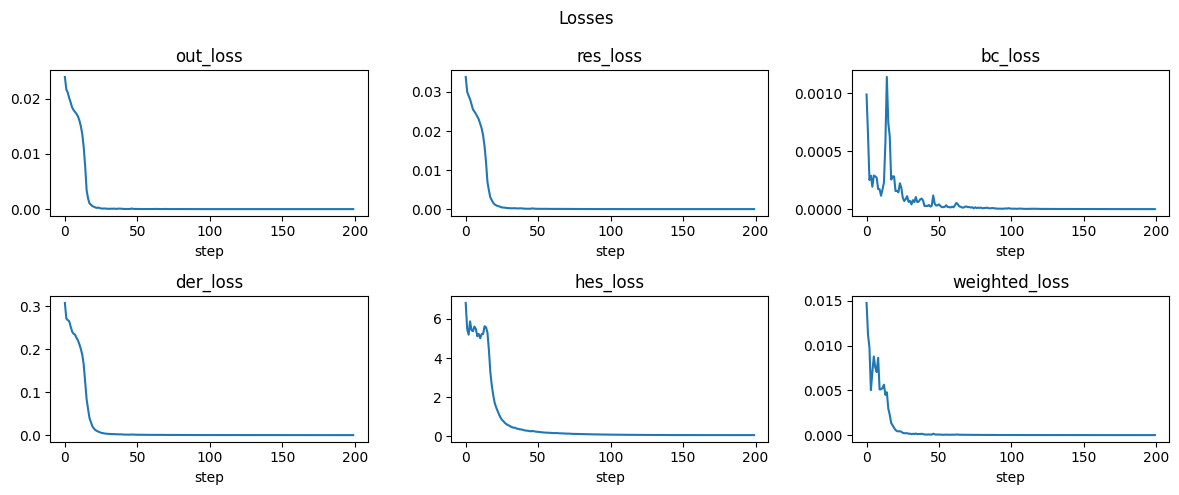


=============== Checkpoint ===============
PDE: Allen-Cahn
PDE parameters in input: ['xi1', 'xi2']
Time in input: False
Space in input: True
Fourier features: 30
|Input units|: 4
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: Norm1
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 0.9833401441574097
	IC: 1.0
	RES: 0.016659872606396675
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
-----------------------------------

In [8]:
models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task{TASK}_{N_EPOCHS}/models2"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train"],
    subkeys=["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "weighted_loss"],
    figsize=(12, 5),
    legend=False,
    title="Losses",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/losses.png"
)

print_model_info(f"{models_dir}/trial0")

Last res_loss: 1.3523766938305926e-05
Last grad norm: 2.246528492833022e-05


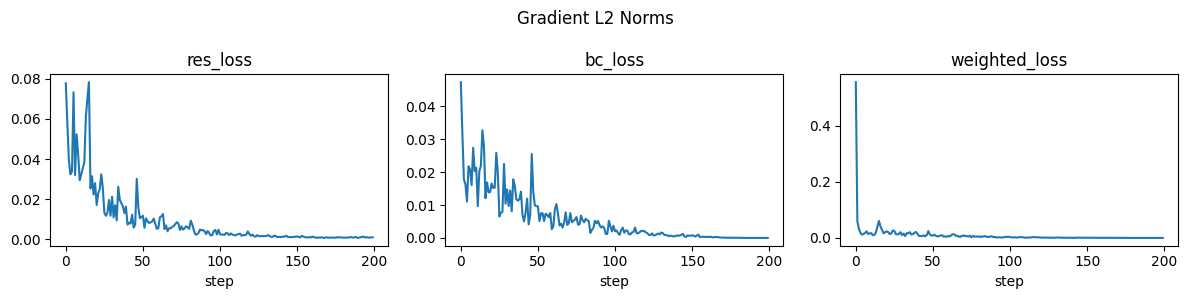

Last value weights res_loss: 0.016659872606396675
Last value weights bc_loss: 0.9833401441574097


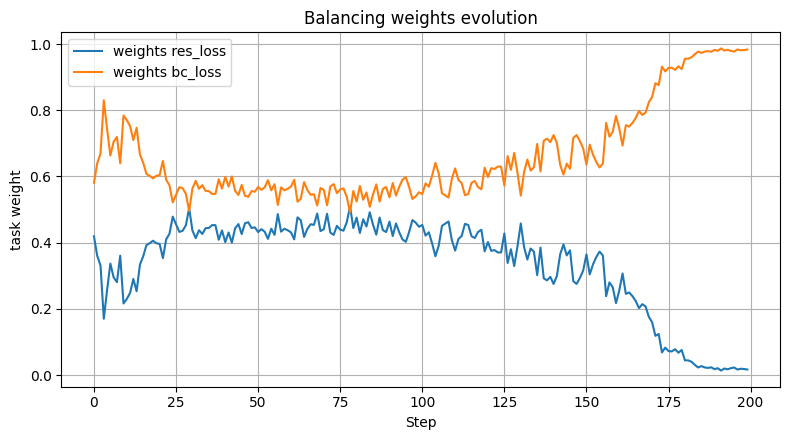

Last value conflicts bc_loss: -0.284999281167984


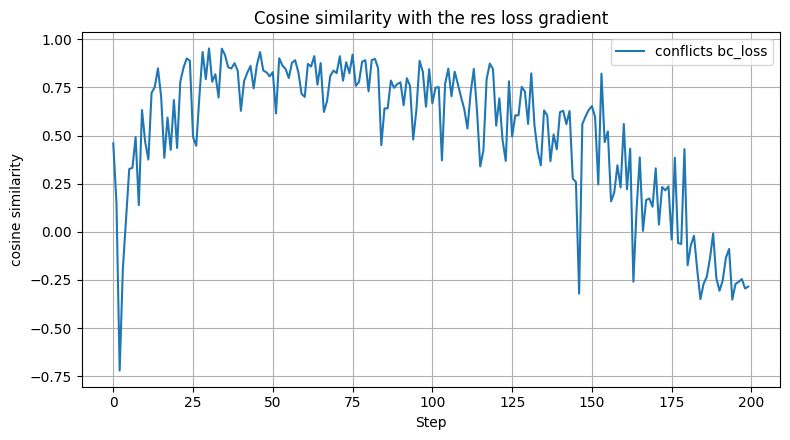

In [9]:
models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task{TASK}_{N_EPOCHS}/models2"
models_dict = {"trial0": load_stats(f"{models_dir}/trial0")}

print(f"Last res_loss: {models_dict['trial0']['train']['res_loss'][-1]}")
print(f"Last grad norm: {models_dict['trial0']['train_loss_grad_norm'][-1][0]}")

plot_model_stats_grid(
        data=f"{models_dir}/trial0",
        keys=["grad_norms"],
        subkeys=["res_loss", "bc_loss", "weighted_loss"],
        figsize=(12, 3),
        legend=False,
        title="Gradient L2 Norms",
        save=SAVE_PLOTS,
        dst_file=f"{models_dir}/plots/grad_norms.png"
    )
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["weights"],
    subkeys=["res_loss", "bc_loss"],
    ylabel="task weight",
    title="Balancing weights evolution",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/weights.png"
)
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["conflicts"],
    subkeys=["bc_loss"],
    ylabel="cosine similarity",
    title="Cosine similarity with the res loss gradient",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/conflicts.png"
)

In [10]:
if CROSS_THE_RUBICON:
    models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task{TASK}_{N_EPOCHS}/models2"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    best_model = resume_model(model_path=f"{models_dir}/trial0/model.pth", device="cpu")

    for x_datasets, s in [(full_datasets, "full_dataset")]:
        os.makedirs(f"{models_dir}/plots/{s}", exist_ok=True)
        for i, ds in tqdm(enumerate(x_datasets), total=len(x_datasets)):
            labeled = compute_prediction(model=best_model, dataset=ds.datasets[0])

            if not os.path.exists(f"{PDE}/data/plots/{s}/true_values{i}.png"):
                os.makedirs(f"{PDE}/data/plots/{s}", exist_ok=True)
                true = extract_targets(dataset=ds.datasets[0])    
                vmins, vmaxs = plot_points_grid(
                    dataset=true,
                    cmap="inferno",
                    save=True,
                    dst_file=f"{PDE}/data/plots/{s}/true_values{i}.png",
                    show=False
                )
                vmins = np.array(vmins)
                vmaxs = np.array(vmaxs)
                np.save(f"{PDE}/data/plots/{s}/vmins{i}.npy", vmins)
                np.save(f"{PDE}/data/plots/{s}/vmaxs{i}.npy", vmaxs)
            else:
                vmins = np.load(f"{PDE}/data/plots/{s}/vmins{i}.npy")
                vmaxs = np.load(f"{PDE}/data/plots/{s}/vmaxs{i}.npy")

            plot_points_grid(
                dataset=labeled,
                cmap="inferno",
                vmins=vmins,
                vmaxs=vmaxs,
                save=True,
                dst_file=f"{models_dir}/plots/{s}/best_model_predictions{i}.png",
                show=False
            );

            differences = compute_prediction_difference(model=best_model, dataset=ds.datasets[0])
            #vmins = len(differences)*[min([t.min() for t in differences.tensors[1:]])]
            #vmaxs = len(differences)*[max([t.max() for t in differences.tensors[1:]])]
            plot_points_grid(
                dataset=differences,
                #vmins=vmins,
                #vmaxs=vmaxs,
                save=True,
                dst_file=f"{models_dir}/plots/{s}/differences{i}.png",
                show=False
            );

        print(f"{s} predictions saved.")

In [11]:
if CROSS_THE_RUBICON:
    to_show = [0]
            
    dataset_name = "full_dataset"
    models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task{TASK}_{N_EPOCHS}/models2"
    
    for i in to_show:
        img = mpimg.imread(f"{PDE}/data/plots/{dataset_name}/true_values{i}.png")
        plt.figure(figsize=(12, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.show()
        for img_name in [f"best_model_predictions{i}", f"differences{i}"]:
            img = mpimg.imread(f"{models_dir}/plots/{dataset_name}/{img_name}.png")
            plt.figure(figsize=(12, 5))
            plt.imshow(img)
            plt.axis("off")
            plt.show()
        print("-------------------------------------------")

In [12]:
models_dirs = [
    f"{PDE}/FullDomainLearning/MultiTask/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2",
    f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task{TASK}_{N_EPOCHS}/models2"
]

models = [resume_model(model_path=f"{models_dir}/trial0/model.pth") for models_dir in models_dirs]
models_names = ["Mfull", f"M{TASK}"]

datasets = [dev_data] + [prepare_dataset(ds) for ds in intra_test_task] + [prepare_dataset(intra_test_datasets)] + [prepare_dataset(inter_test_datasets)]
datasets_names = [f"dev{TASK}"] + [f"intra_test{i}" for i in range(n_tasks)] + [f"intra_test"] + [f"inter_test"]
dst_files = [f"dev_dataset{TASK}"] + [f"intra_test_dataset{i}" for i in range(n_tasks)] + [f"intra_test_dataset"] + [f"inter_test_dataset"]

for s in dst_files:
    os.makedirs(f"{models_dirs[-1]}/plots", exist_ok=True)
dst_files = [f"{models_dirs[-1]}/plots/{s}.png" for s in dst_files]

plot_performance_comparison(
    models=models,
    models_names=models_names,
    datasets=datasets,
    datasets_names=datasets_names,
    subset={"x": [-1.0, 1.0], "y": [-1.0, 1.0]},
    figsize=(11, 3),
    bar_labels=True,
    yaxis_visible=True,
    colors=["firebrick", "tab:blue"],
    save=SAVE_PLOTS,
    dst_files=dst_files,
    show=False
)

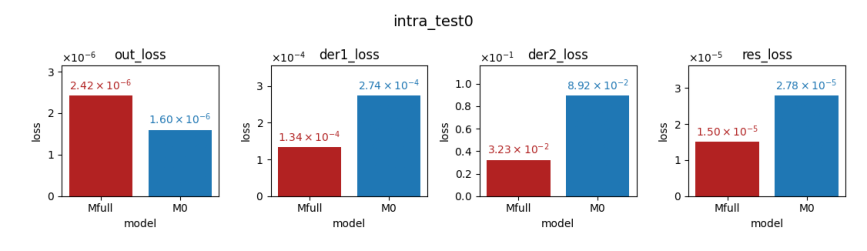

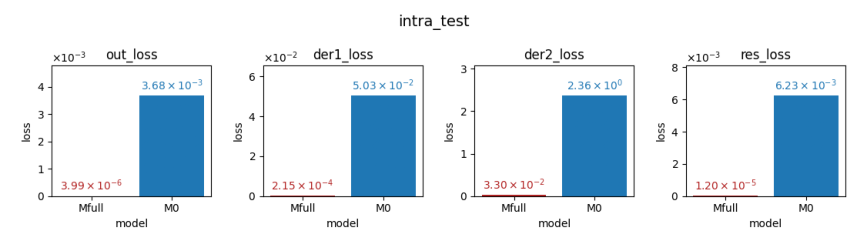

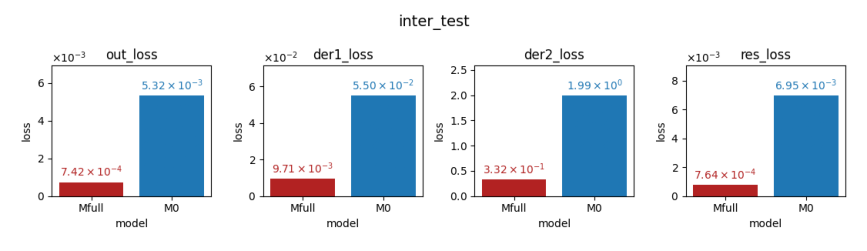

In [13]:
task = TASK
dataset_name = f"intra_test_dataset{task}"

models_dir = f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_{CLIP}/Task{TASK}_{N_EPOCHS}/models2"
img_file = f"{models_dir}/plots/{dataset_name}.png"
img = mpimg.imread(img_file)
plt.figure(figsize=(11, 3))
plt.imshow(img)
plt.axis("off")
plt.show()

dataset_name = f"intra_test_dataset"

img_file = f"{models_dir}/plots/{dataset_name}.png"
img = mpimg.imread(img_file)
plt.figure(figsize=(11, 3))
plt.imshow(img)
plt.axis("off")
plt.show()

dataset_name = f"inter_test_dataset"

img_file = f"{models_dir}/plots/{dataset_name}.png"
img = mpimg.imread(img_file)
plt.figure(figsize=(11, 3))
plt.imshow(img)
plt.axis("off")
plt.show()

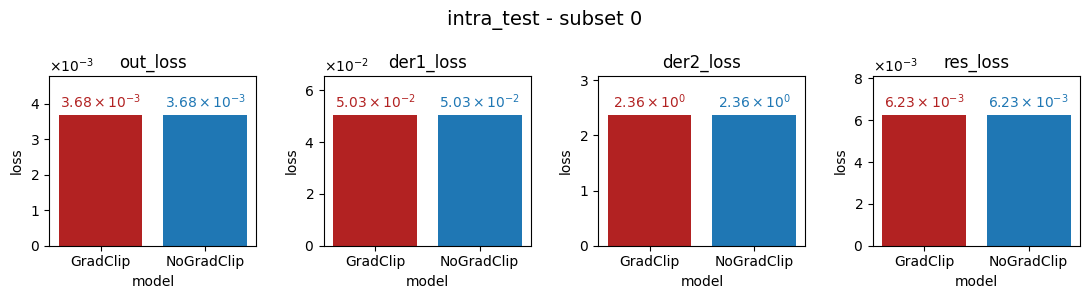

In [14]:
if CLIP_GRAD == False:
    subsets = [{"x": [-1.0, 1.0], "y": [-1.0, 1.0]}]
    
    models_dirs = [
        f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_GradClip/Task{TASK}_{N_EPOCHS}/models2",
        f"{PDE}/TaskIncrementalLearning/{ACTUAL_MODE}{LR}_{DWA_MODE}_NoGradClip/Task{TASK}_{N_EPOCHS}/models2"
    ]
    models = [resume_model(model_path=f"{models_dir}/trial0/model.pth") for models_dir in models_dirs]
    models_names = [f"GradClip", f"NoGradClip"]
    
    datasets = [prepare_dataset(intra_test_datasets)]
    
    for i, subset in enumerate(subsets):
        datasets_names = ["intra_test"]
        datasets_names = [f"{s} - subset {i}" for s in datasets_names]
    
        dst_files = ["intra_test_dataset"]
        for s in dst_files:
            os.makedirs(f"{models_dirs[0]}/plots/{s}", exist_ok=True)
        dst_files = [f"{models_dirs[0]}/plots/{s}/clip_grad_or_not_subset{i}.png" for s in dst_files]
    
        plot_performance_comparison(
            models=models,
            models_names=models_names,
            datasets=datasets,
            datasets_names=datasets_names,
            subset=subset,
            figsize=(11, 3),
            bar_labels=True,
            yaxis_visible=True,
            colors=["firebrick", "tab:blue"],
            save=SAVE_PLOTS,
            dst_files=dst_files,
            show=True
        )